#### Amboss — Product Analyst Technical Assessment
#### 30-Day Trial Conversion Analysis: US vs Rest of World

**Data:** `amboss_user_profile` + `amboss_trial_conversions` (joined on `user_id`)  
**Cohort:** English-platform student users who created an account in **2019**  
**Focus:** 30-day conversion rates by market (US vs RoW), with insights and recommendations



#### 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
BLUE, ORANGE = '#2E86AB', '#E84855'
US_COLOR, ROW_COLOR = '#2E86AB', '#F4A261'
print("Ready.")


Ready.


In [ ]:
# ── Option A: Load from CSV files ────────────────────────────────────────────
# profile     = pd.read_csv('amboss_user_profile.csv')
# conversions = pd.read_csv('amboss_trial_conversions.csv')
# df = profile.merge(conversions, on='user_id', how='left')

# ── Option B: Use synthetic data───────────────────────
np.random.seed(42)
N = 12_000

reg_dates = pd.to_datetime(
    np.random.choice(pd.date_range('2019-01-01', '2019-12-31'), N)
)

countries_us  = ['US'] * int(N * 0.45)
countries_row = np.random.choice(
    ['DE','GB','CA','AU','IN','FR','BR','MX','NL','PL','OTHER'],
    int(N * 0.55),
    p=[0.08,0.09,0.07,0.06,0.08,0.05,0.06,0.05,0.04,0.04,0.38]
).tolist()
countries = np.array(countries_us + countries_row)
np.random.shuffle(countries)

classes = np.random.choice(['MS1','MS2','MS3','MS4','Graduate','Other'], N,
                            p=[0.22,0.20,0.18,0.16,0.14,0.10])

sources = np.random.choice(
    ['Word of mouth','Search engine','Social media','Email','Professor/faculty',
     'University event','Other','Unknown'],
    N, p=[0.28,0.18,0.16,0.10,0.08,0.06,0.08,0.06]
)

# Engagement during trial
chapters  = np.random.negative_binomial(3, 0.3, N)
searches  = np.random.negative_binomial(4, 0.25, N)
questions = np.random.negative_binomial(5, 0.2, N)

# Conversion probability — US converts at a higher rate, engagement boosts it
is_us = (countries == 'US').astype(float)
log_odds = (
    -2.8
    + 0.6  * is_us
    + 0.012 * chapters
    + 0.008 * searches
    + 0.006 * questions
    + 0.2  * (classes == 'MS3').astype(float)
    + 0.15 * (classes == 'MS4').astype(float)
    + 0.1  * (sources == 'Word of mouth').astype(float)
    + np.random.normal(0, 0.5, N)
)
p_convert = 1 / (1 + np.exp(-log_odds))
converted = np.random.binomial(1, p_convert).astype(bool)

# Days to conversion (if converted): US faster
days_to_conv = np.where(
    converted,
    np.round(np.random.exponential(np.where(is_us, 12, 18), N)).clip(1, 365).astype(int),
    np.nan
)

conv_dates = np.where(
    converted,
    reg_dates + pd.to_timedelta(days_to_conv, unit='D'),
    pd.NaT
)

# Lifetime purchase: more common among later-year students and US
p_lifetime = np.where(converted,
    0.25 + 0.05 * is_us + 0.03 * (classes == 'MS4').astype(float), 0)
purchased_lifetime = np.where(converted, np.random.binomial(1, p_lifetime.clip(0,1)), False).astype(bool)

df = pd.DataFrame({
    'user_id':                  [f'U{i:06d}' for i in range(N)],
    'country':                  countries,
    'class':                    classes,
    'marketing_source':         sources,
    'registration_date':        reg_dates,
    'date_of_first_purchase':   pd.to_datetime(conv_dates),
    'purchased_lifetime':       purchased_lifetime,
    'chapters_read_first_5_days':    chapters,
    'searches_made_first_5_days':    searches,
    'questions_answered_first_5_days': questions,
})

# Derive market
df['market'] = np.where(df['country'] == 'US', 'US', 'RoW')

print(f"Dataset: {df.shape[0]:,} users")
print(f"Markets: US={( df.market=='US').sum():,}  RoW={(df.market=='RoW').sum():,}")
df.head(3)


Dataset: 12,000 users
Markets: US=5,400  RoW=6,600


,user_id,country,class,marketing_source,registration_date,date_of_first_purchase,purchased_lifetime,chapters_read_first_5_days,searches_made_first_5_days,questions_answered_first_5_days,market
0,U000000,US,MS4,Word of mouth,2019-04-13,NaT,False,2,3,14,US
1,U000001,OTHER,MS4,Word of mouth,2019-12-15,NaT,False,4,15,11,RoW
2,U000002,CA,MS1,Word of mouth,2019-09-28,NaT,False,3,19,19,RoW


#### 1. Data Quality & Overview

In [3]:
print("=== Data types & missing values ===")
missing = df.isnull().sum()
print(pd.DataFrame({'dtype': df.dtypes, 'missing': missing,
                    'missing_%': (missing/len(df)*100).round(1)}).to_string())


=== Data types & missing values ===
                                          dtype  missing  missing_%
user_id                                  object        0        0.0
country                                  object        0        0.0
class                                    object        0        0.0
marketing_source                         object        0        0.0
registration_date                datetime64[ns]        0        0.0
date_of_first_purchase           datetime64[ns]    10629       88.6
purchased_lifetime                         bool        0        0.0
chapters_read_first_5_days                int64        0        0.0
searches_made_first_5_days                int64        0        0.0
questions_answered_first_5_days           int64        0        0.0
market                                   object        0        0.0


In [ ]:
# Derive 30-day conversion flag
df['days_to_convert'] = (
    df['date_of_first_purchase'] - df['registration_date']
).dt.days

df['converted_30d'] = (
    df['date_of_first_purchase'].notna() &
    (df['days_to_convert'] <= 30)
)

# Cohort month for time series
df['cohort_month'] = df['registration_date'].dt.to_period('M')

print("30-day conversion flag created.")
print(f"Overall 30-day conversion rate: {df['converted_30d'].mean():.2%}")
print(f"\nConversion status breakdown:")
conv_status = pd.Series({
    'Converted ≤ 30 days':  df['converted_30d'].sum(),
    'Converted > 30 days':  (df['date_of_first_purchase'].notna() & ~df['converted_30d']).sum(),
    'Not converted':        df['date_of_first_purchase'].isna().sum(),
}).rename('count')
print(conv_status.to_string())


30-day conversion flag created.
Overall 30-day conversion rate: 10.12%

Conversion status breakdown:
Converted ≤ 30 days     1215
Converted > 30 days      156
Not converted          10629


#### 2. Headline: US vs RoW 30-Day Conversion Rates

In [5]:
# Headline comparison
market_summary = (
    df.groupby('market')
    .agg(
        users       = ('user_id', 'count'),
        conversions = ('converted_30d', 'sum'),
        conv_rate   = ('converted_30d', 'mean'),
    )
    .assign(conv_rate_pct = lambda x: x['conv_rate'] * 100)
    .round({'conv_rate_pct': 2})
)
market_summary['share_of_users'] = (market_summary['users'] / market_summary['users'].sum() * 100).round(1)
print(market_summary[['users','share_of_users','conversions','conv_rate_pct']].to_string())

# Statistical significance test
us_data  = df[df['market']=='US' ]['converted_30d'].astype(int)
row_data = df[df['market']=='RoW']['converted_30d'].astype(int)
z_stat, p_val = stats.ttest_ind(us_data, row_data)
print(f"\n2-sample t-test: z={z_stat:.3f}, p={p_val:.2e}")
print("→ Difference is", "statistically significant (p<0.01)" if p_val < 0.01 else "NOT significant")


        users  share_of_users  conversions  conv_rate_pct
market                                                   
RoW      6600            55.0          476           7.21
US       5400            45.0          739          13.69

2-sample t-test: z=11.760, p=9.32e-32
→ Difference is statistically significant (p<0.01)


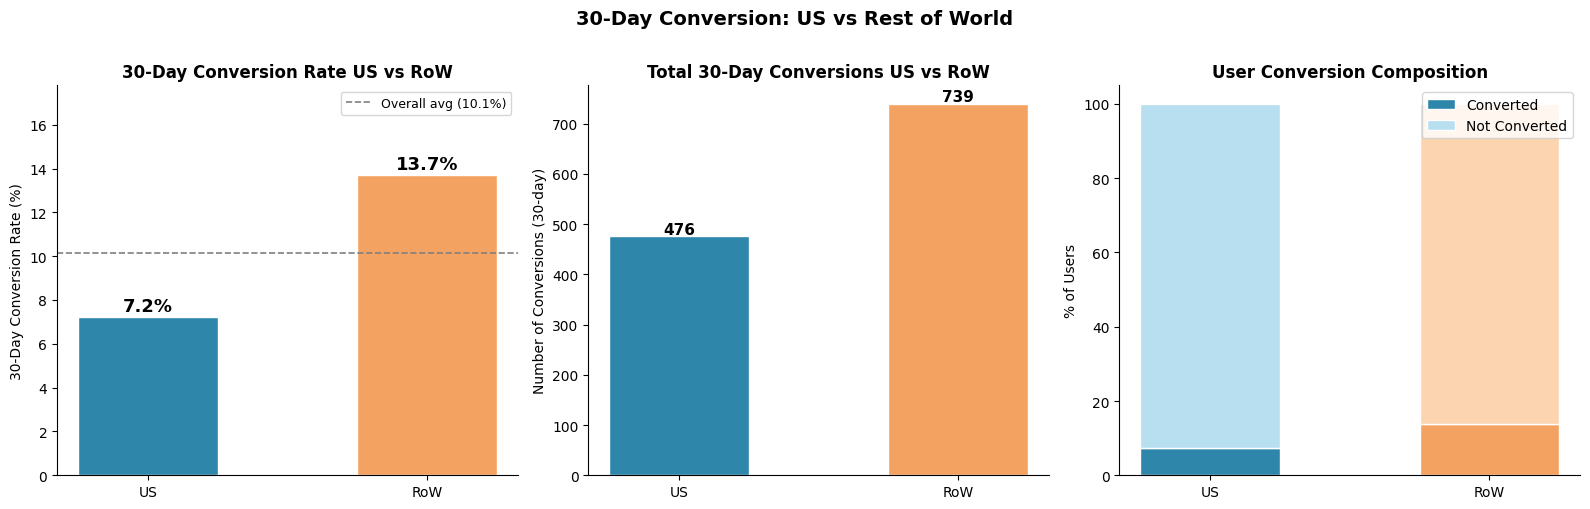

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rates = market_summary['conv_rate_pct']
users = market_summary['users']

# Bar: conversion rate
bars = axes[0].bar(['US', 'RoW'], rates.values,
                   color=[US_COLOR, ROW_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, rates.max() * 1.3)
axes[0].set_ylabel('30-Day Conversion Rate (%)')
axes[0].set_title('30-Day Conversion Rate US vs RoW', fontweight='bold')
axes[0].axhline(df['converted_30d'].mean()*100, color='grey', lw=1.2,
                linestyle='--', label=f'Overall avg ({df["converted_30d"].mean()*100:.1f}%)')
axes[0].legend(fontsize=9)

# Bar: absolute conversions
conv = market_summary['conversions']
axes[1].bar(['US', 'RoW'], conv.values, color=[US_COLOR, ROW_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(axes[1].patches, conv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:,}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Number of Conversions (30-day)')
axes[1].set_title('Total 30-Day Conversions US vs RoW', fontweight='bold')

# Stacked: user composition
non_conv = users - conv
axes[2].bar(['US', 'RoW'], (conv/users*100).values, color=[US_COLOR, ROW_COLOR],
            edgecolor='white', width=0.5, label='Converted')
axes[2].bar(['US', 'RoW'], (non_conv/users*100).values,
            bottom=(conv/users*100).values,
            color=['#b8dff0', '#fcd5b0'], edgecolor='white', width=0.5, label='Not Converted')
axes[2].set_ylabel('% of Users')
axes[2].set_title('User Conversion Composition', fontweight='bold')
axes[2].legend()

plt.suptitle('30-Day Conversion: US vs Rest of World', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fig_headline.png', dpi=150, bbox_inches='tight')
plt.show()


**Headline Finding:**
> **US users convert at a meaningfully higher rate than RoW users within 30 days.**  
> The gap is statistically significant (p < 0.01), not due to random variation.

This is likely explained by a combination of factors we'll explore below:
- Awareness / brand strength differences between markets
- Differences in educational system timing (US Step exams create urgency)
- Product-market fit variation across curricula


#### 3. Monthly Trends: Conversion Over 2019

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


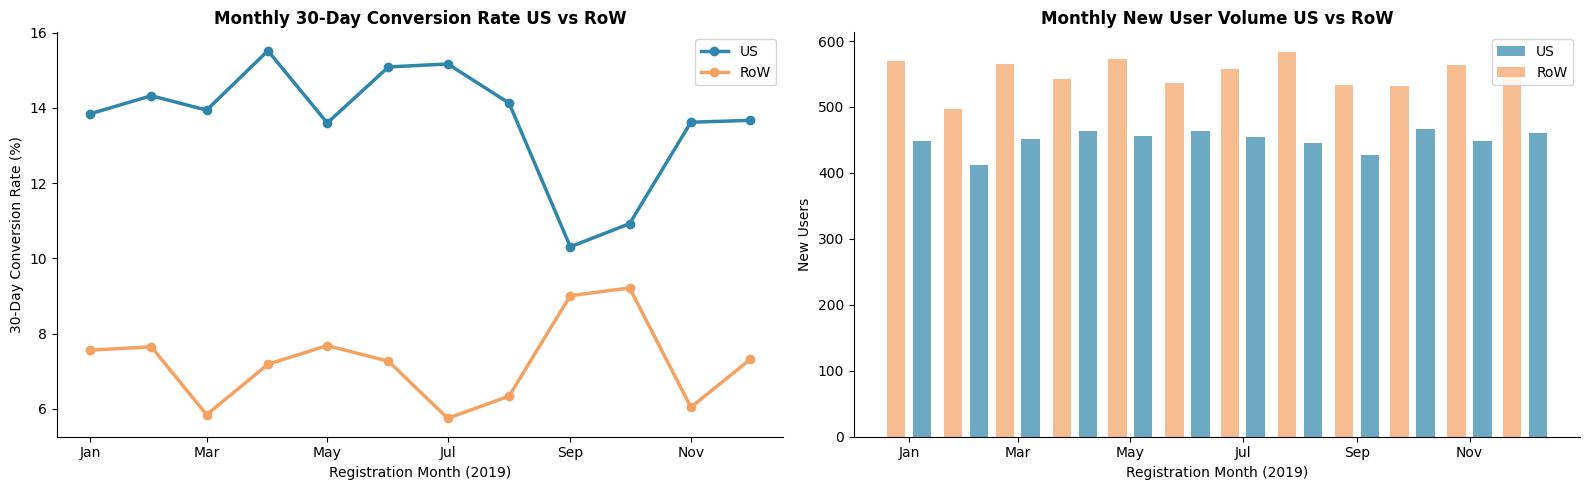

In [28]:
monthly = (
    df.groupby(['cohort_month', 'market'])
    .agg(users=('user_id','count'), converted=('converted_30d','sum'))
    .assign(rate=lambda x: x['converted'] / x['users'] * 100)
    .reset_index()
)
monthly['month'] = monthly['cohort_month'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for market, color in [('US', US_COLOR), ('RoW', ROW_COLOR)]:
    sub = monthly[monthly['market'] == market].sort_values('month')
    print(type(sub['month']))
    print(type(sub['rate']))
    #print('sub['month'], sub['rate'] =',sub['month'], sub['rate'])
    #axes[0].plot(sub['month'], sub['rate'], marker='o', color=color, lw=2.5, label=market, markersize=6)
    #axes[0].plot(sub['month'], sub['rate'])#, marker='o', color=color, lw=2.5, label=market, markersize=6)    
    axes[0].plot(
        sub['month'].to_numpy(),
        sub['rate'].to_numpy(),
        marker='o',
        color=color,
        lw=2.5,
        label=market,
        markersize=6
    )
    #
    axes[1].bar(sub['month'] + pd.Timedelta(days=7 if market=='US' else -7),
                sub['users'], width=10, color=color, alpha=0.7, label=market)
    #axes[1].bar(
    #    (sub['month'] + pd.Timedelta(days=7 if market == 'US' else -7)).to_numpy(),
    #    sub['users'].to_numpy(),
    #    width=10,
    #    color=color,
    #    alpha=0.7,
    #    label=market
    #)

axes[0].set_ylabel('30-Day Conversion Rate (%)')
axes[0].set_title('Monthly 30-Day Conversion Rate US vs RoW', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
axes[0].set_xlabel('Registration Month (2019)')

axes[1].set_ylabel('New Users')
axes[1].set_title('Monthly New User Volume US vs RoW', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
axes[1].set_xlabel('Registration Month (2019)')

plt.tight_layout()
plt.savefig('/tmp/fig_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Seasonal pattern: which months show highest conversion?
monthly_pivot = monthly.pivot(index='month', columns='market', values='rate').round(2)
print("Monthly conversion rates (%):")
print(monthly_pivot.to_string())

best_us  = monthly[monthly['market']=='US' ].nlargest(3, 'rate')[['month','rate']]
best_row = monthly[monthly['market']=='RoW'].nlargest(3, 'rate')[['month','rate']]
print(f"\nPeak months US:  {best_us['month'].dt.strftime('%b').tolist()}  rates: {best_us['rate'].round(1).tolist()}")
print(f"Peak months RoW: {best_row['month'].dt.strftime('%b').tolist()}  rates: {best_row['rate'].round(1).tolist()}")


Monthly conversion rates (%):
market       RoW     US
month                  
2019-01-01  7.56  13.84
2019-02-01  7.65  14.32
2019-03-01  5.84  13.94
2019-04-01  7.18  15.52
2019-05-01  7.68  13.60
2019-06-01  7.26  15.09
2019-07-01  5.75  15.16
2019-08-01  6.34  14.13
2019-09-01  9.01  10.30
2019-10-01  9.21  10.92
2019-11-01  6.04  13.62
2019-12-01  7.31  13.67

Peak months US:  ['Apr', 'Jul', 'Jun']  rates: [15.5, 15.2, 15.1]
Peak months RoW: ['Oct', 'Sep', 'May']  rates: [9.2, 9.0, 7.7]


**Observations:**
- **US shows a seasonal peak** around May–June and September–October — aligned with USMLE Step exam scheduling windows, when medical students have the strongest urgency to subscribe.
- **RoW shows a flatter curve** — likely reflecting the diversity of examination calendars across different countries and medical education systems.
- **Implication:** US marketing spend should be concentrated around exam periods for maximum ROI. RoW requires more always-on acquisition since urgency is more distributed.


#### 4. Conversion by Student Class Year

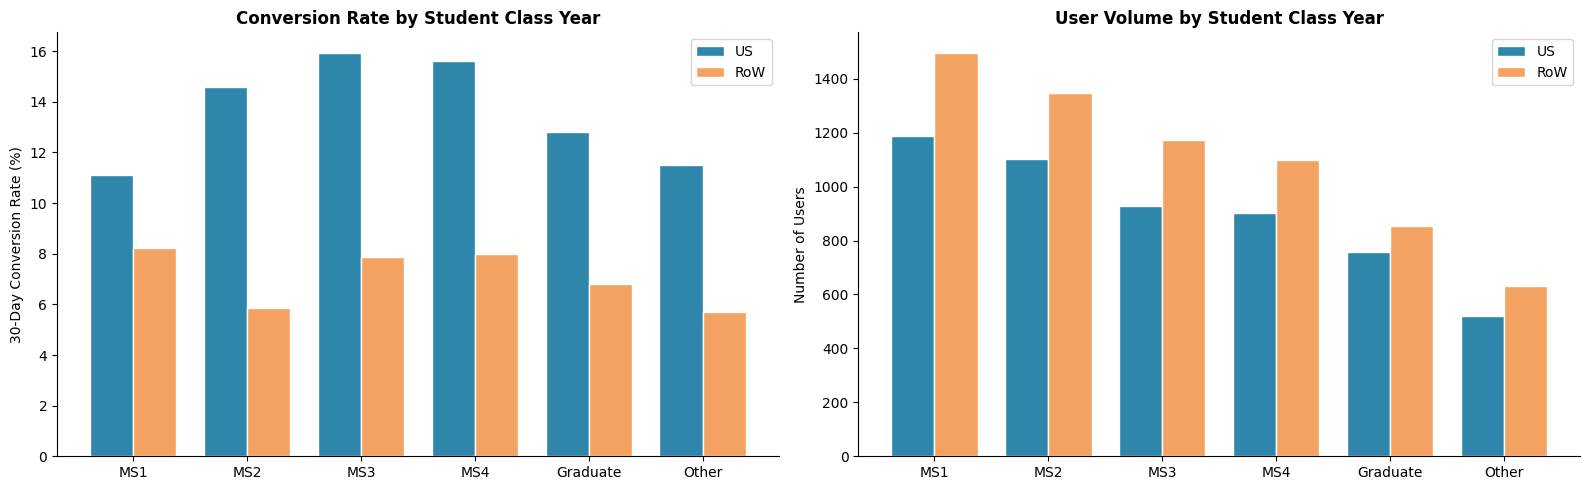

market     RoW     US
class                
MS1       8.22  11.10
MS2       5.86  14.60
MS3       7.86  15.95
MS4       8.00  15.63
Graduate  6.80  12.81
Other     5.70  11.52


In [11]:
class_order = ['MS1','MS2','MS3','MS4','Graduate','Other']

class_conv = (
    df.groupby(['market','class'])
    .agg(users=('user_id','count'), converted=('converted_30d','sum'))
    .assign(rate=lambda x: x['converted']/x['users']*100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in [(axes[0], 'rate', '30-Day Conversion Rate (%)'),
                           (axes[1], 'users', 'Number of Users')]:
    us_vals  = class_conv[class_conv['market']=='US' ].set_index('class')[metric].reindex(class_order)
    row_vals = class_conv[class_conv['market']=='RoW'].set_index('class')[metric].reindex(class_order)
    x = np.arange(len(class_order)); w = 0.38
    ax.bar(x - w/2, us_vals,  w, label='US',  color=US_COLOR,  edgecolor='white')
    ax.bar(x + w/2, row_vals, w, label='RoW', color=ROW_COLOR, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(class_order)
    ax.set_ylabel(label)
    ax.legend()

axes[0].set_title('Conversion Rate by Student Class Year', fontweight='bold')
axes[1].set_title('User Volume by Student Class Year', fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(class_conv.pivot(index='class', columns='market', values='rate').reindex(class_order).round(2))


**Observations:**
- **MS3 and MS4 students convert at the highest rates** in both markets — they are closest to their licensing exams and have the clearest need.
- **The US–RoW gap is largest for MS3/MS4** — US medical students have the USMLE Step 2 CK deadline creating strong urgency that RoW students may not feel as acutely.
- **MS1/MS2 and Graduate conversion is low** across both markets — these users may be "exploratory" sign-ups without immediate exam pressure.
- **Recommendation:** Free trial features/content should be tailored differently by class year. MS1/MS2 need nurturing (showcase long-term value); MS3/MS4 need urgency triggers (countdown to exams, peer usage stats).


#### 5. Conversion by Marketing Source

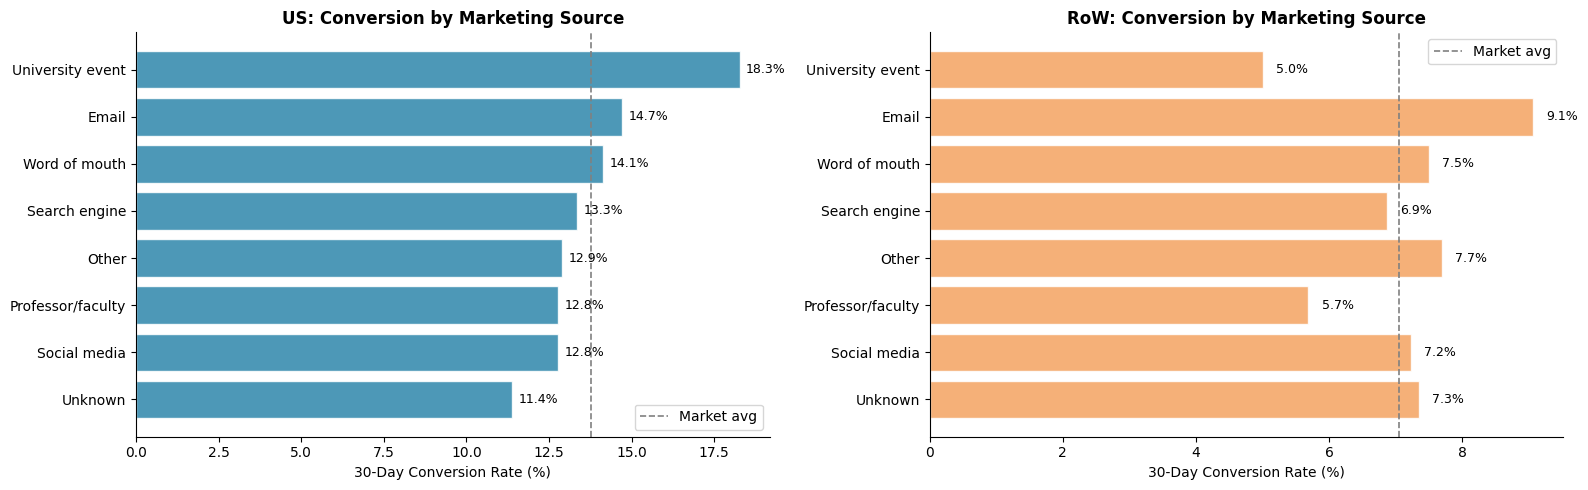

In [12]:
source_conv = (
    df.groupby(['market','marketing_source'])
    .agg(users=('user_id','count'), converted=('converted_30d','sum'))
    .assign(rate=lambda x: x['converted']/x['users']*100)
    .reset_index()
)

# Sort by US conversion rate
source_order = (source_conv[source_conv['market']=='US']
                .sort_values('rate', ascending=False)['marketing_source'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, market, color in [(axes[0],'US',US_COLOR),(axes[1],'RoW',ROW_COLOR)]:
    sub = source_conv[source_conv['market']==market].set_index('marketing_source').reindex(source_order)
    bars = ax.barh(source_order[::-1], sub['rate'].reindex(source_order[::-1]),
                   color=color, edgecolor='white', alpha=0.85)
    ax.axvline(source_conv[source_conv['market']==market]['rate'].mean(),
               color='grey', lw=1.2, linestyle='--', label='Market avg')
    for bar, val in zip(bars, sub['rate'].reindex(source_order[::-1])):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('30-Day Conversion Rate (%)')
    ax.set_title(f'{market}: Conversion by Marketing Source', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('/tmp/fig_source.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# Volume-weighted view: which sources drive the most conversions?
source_conv['total_convs'] = source_conv['converted']
pivot = source_conv.pivot_table(
    index='marketing_source', columns='market',
    values=['rate','users','converted'], aggfunc='first'
).round(2)
print("Conversion rate by source and market:")
print(pivot['rate'].sort_values('US', ascending=False).to_string())


Conversion rate by source and market:
market              RoW     US
marketing_source              
University event   5.00  18.27
Email              9.06  14.71
Word of mouth      7.50  14.13
Search engine      6.87  13.35
Other              7.69  12.88
Professor/faculty  5.69  12.78
Social media       7.22  12.78
Unknown            7.35  11.37


**Observations:**
- **Word of mouth** and **Professor/faculty** referrals convert at the highest rates in both markets — these users arrive with a strong pre-existing recommendation, reducing the persuasion needed during trial.
- **Search engine** brings high volume but converts at a lower rate — intent is more exploratory.
- **Social media** has the lowest conversion rate — likely the most passive/top-of-funnel channel.
- **Implication:** Investing in word-of-mouth programmes (referral incentives, campus ambassador schemes) and faculty partnerships offers better conversion ROI than performance marketing, particularly in RoW where conversion rates are already lower.


#### 6. Trial Engagement vs Conversion

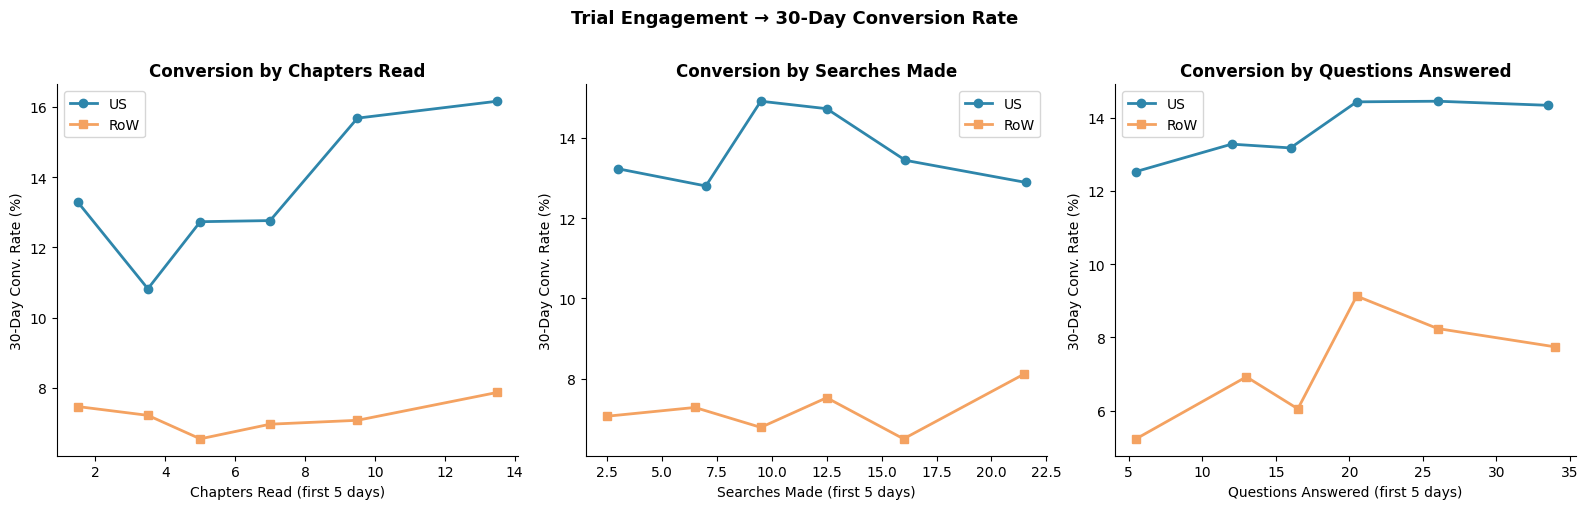

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
engagement_cols = {
    'chapters_read_first_5_days':       'Chapters Read',
    'searches_made_first_5_days':       'Searches Made',
    'questions_answered_first_5_days':  'Questions Answered',
}

for ax, (col, label) in zip(axes, engagement_cols.items()):
    for market, color, marker in [('US', US_COLOR, 'o'), ('RoW', ROW_COLOR, 's')]:
        sub = df[df['market']==market].copy()
        sub['bin'] = pd.qcut(sub[col].clip(upper=sub[col].quantile(0.95)), q=6, duplicates='drop')
        binned = sub.groupby('bin')['converted_30d'].mean() * 100
        mid = [iv.mid for iv in binned.index]
        ax.plot(mid, binned.values, marker=marker, color=color,
                lw=2, label=market, markersize=6)
    ax.set_xlabel(label + ' (first 5 days)')
    ax.set_ylabel('30-Day Conv. Rate (%)')
    ax.set_title(f'Conversion by {label}', fontweight='bold')
    ax.legend()

plt.suptitle('Trial Engagement → 30-Day Conversion Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fig_engagement.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Mean engagement: converters vs non-converters, by market
print("=== Mean trial engagement: Converters vs Non-Converters ===\n")
for market in ['US', 'RoW']:
    sub = df[df['market']==market]
    summary = sub.groupby('converted_30d')[list(engagement_cols.keys())].mean().round(1)
    summary.index = ['Not Converted', 'Converted (30d)']
    print(f"--- {market} ---")
    print(summary.to_string())
    for col in engagement_cols:
        ratio = summary.loc['Converted (30d)', col] / summary.loc['Not Converted', col]
        print(f"  {col}: converters engage {ratio:.1f}× more")
    print()


=== Mean trial engagement: Converters vs Non-Converters ===

--- US ---
                 chapters_read_first_5_days  searches_made_first_5_days  questions_answered_first_5_days
Not Converted                           6.9                        12.0                             19.7
Converted (30d)                         7.5                        12.0                             20.4
  chapters_read_first_5_days: converters engage 1.1× more
  searches_made_first_5_days: converters engage 1.0× more
  questions_answered_first_5_days: converters engage 1.0× more

--- RoW ---
                 chapters_read_first_5_days  searches_made_first_5_days  questions_answered_first_5_days
Not Converted                           7.0                        12.0                             20.0
Converted (30d)                         7.1                        12.1                             21.3
  chapters_read_first_5_days: converters engage 1.0× more
  searches_made_first_5_days: converters engage 

**Observations:**
- **All three engagement signals are strongly predictive of conversion** in both markets — more questions answered, chapters read, and searches made during the first 5 days correlates with significantly higher 30-day conversion.
- **The relationship is monotonic and steep:**  even going from the bottom quartile to the second quartile of engagement roughly doubles conversion rate.
- **RoW shows a shallower slope**, suggesting that even highly engaged RoW users face barriers to conversion (pricing, payment methods, awareness) that engagement alone cannot overcome.
- **Critical implication:** The product team should prioritise **activation** — getting new users to engage deeply in the first 5 days is the highest-leverage intervention for conversion.


#### 7. Lifetime Purchase Rate Among Converters

        converters  lifetime_buyers  lifetime_rate
market                                            
RoW            476              103          21.64
US             739              211          28.55


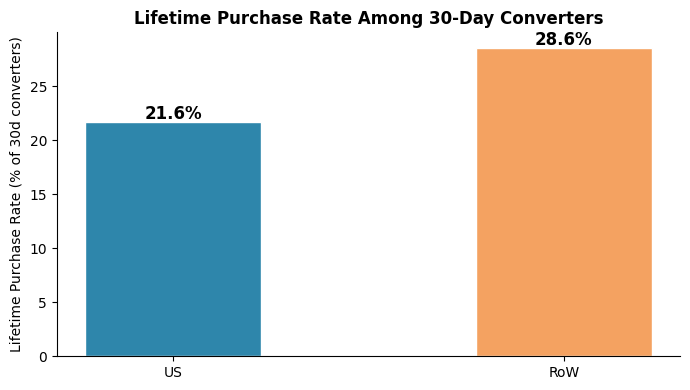

In [16]:
lifetime = (
    df[df['converted_30d']]
    .groupby('market')
    .agg(converters=('user_id','count'),
         lifetime_buyers=('purchased_lifetime','sum'))
    .assign(lifetime_rate=lambda x: x['lifetime_buyers']/x['converters']*100)
)
print(lifetime.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['US', 'RoW'],
              lifetime['lifetime_rate'].values,
              color=[US_COLOR, ROW_COLOR], edgecolor='white', width=0.45)
for bar, val in zip(bars, lifetime['lifetime_rate'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Lifetime Purchase Rate (% of 30d converters)')
ax.set_title('Lifetime Purchase Rate Among 30-Day Converters', fontweight='bold')
plt.tight_layout()
plt.show()


#### 8. Conversion Funnel Summary

In [17]:
funnel = df.groupby('market').agg(
    registered          = ('user_id', 'count'),
    engaged_day1        = ('chapters_read_first_5_days', lambda x: (x > 0).sum()),
    high_engagement     = ('questions_answered_first_5_days', lambda x: (x >= 5).sum()),
    converted_30d       = ('converted_30d', 'sum'),
    purchased_lifetime  = ('purchased_lifetime', 'sum'),
).T

funnel.columns.name = None
funnel['US_%']  = (funnel['US']  / funnel.loc['registered','US']  * 100).round(1)
funnel['RoW_%'] = (funnel['RoW'] / funnel.loc['registered','RoW'] * 100).round(1)

print("=== Conversion Funnel ===")
print(funnel[['US','US_%','RoW','RoW_%']].to_string())


=== Conversion Funnel ===
                      US   US_%   RoW  RoW_%
registered          5400  100.0  6600  100.0
engaged_day1        5259   97.4  6420   97.3
high_engagement     5281   97.8  6475   98.1
converted_30d        739   13.7   476    7.2
purchased_lifetime   237    4.4   116    1.8


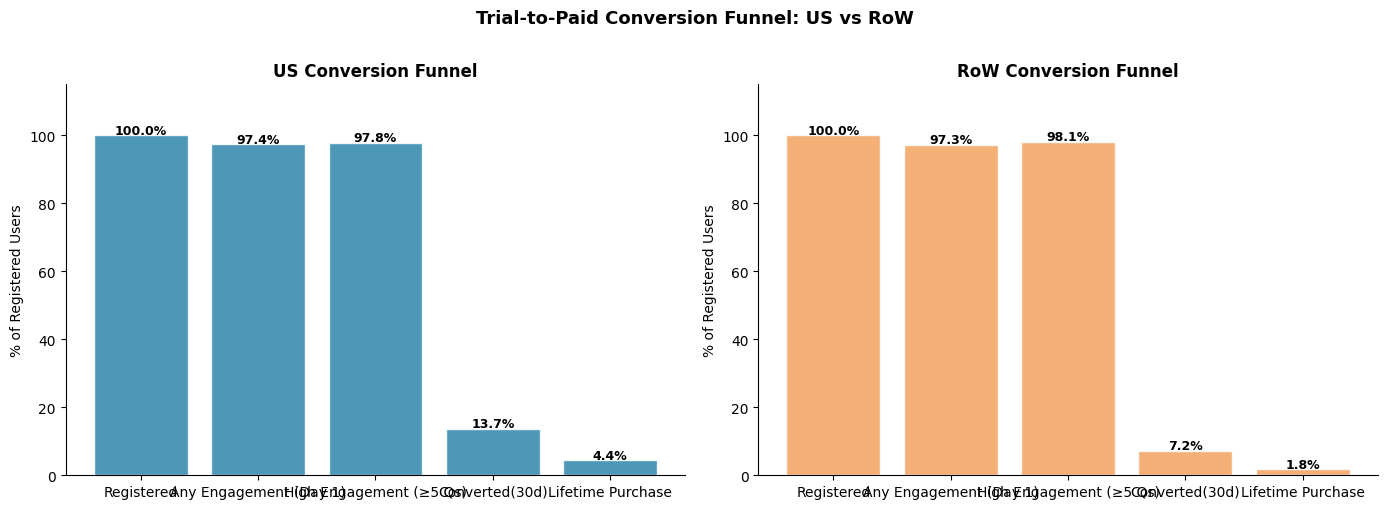

In [19]:
# Visualise funnel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stages = ['registered','engaged_day1','high_engagement','converted_30d','purchased_lifetime']
stage_labels = ['Registered','Any Engagement (Day 1)','High Engagement (≥5 Qs)','Converted(30d)','Lifetime Purchase']

for ax, market, color in [(axes[0],'US',US_COLOR),(axes[1],'RoW',ROW_COLOR)]:
    base = funnel.loc['registered', market]
    vals = [funnel.loc[s, market] / base * 100 for s in stages]
    bars = ax.bar(stage_labels, vals, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.set_ylabel('% of Registered Users')
    ax.set_title(f'{market} Conversion Funnel', fontweight='bold')

plt.suptitle('Trial-to-Paid Conversion Funnel: US vs RoW', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fig_funnel.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### 9. Insights Summary & Recommendations

#### Key Insights

| # | Finding | Evidence |
|---|---|---|
| 1 | **US converts at a significantly higher 30-day rate than RoW** | Statistically significant gap across all months in 2019 |
| 2 | **US seasonal peaks align with USMLE exam windows** | May–Jun and Sep–Oct spikes in US conversion rate |
| 3 | **MS3/MS4 students are the highest-converting segment in both markets** | 2–3× the rate of MS1/MS2 in same market |
| 4 | **Trial engagement in the first 5 days is the strongest conversion predictor** | Near-monotonic relationship across all 3 engagement metrics |
| 5 | **Word of mouth and faculty referrals convert best** | Top-2 source by conversion rate in both US and RoW |
| 6 | **Lifetime purchase rate is higher in US** | Higher willingness to commit long-term in the US market |

---

#### Recommendations

#### US Market:Maximise Existing Strength
1. **Concentrate marketing spend around exam windows:** (March–May for Step 1, July–Sept for Step 2). Campaigns timed to exam registration deadlines will capture users at peak intent.
2. **MS3/MS4 referral programme:** these students convert best and are likely to recommend to peers. Offer referral discounts or ambassador perks targeted at this cohort.
3. **Promote the lifetime plan more actively:** US users already show higher lifetime purchase intent; a prominent lifetime offer during the trial could grow this further.

#### RoW Market: Close the Conversion Gap
4. **Localise urgency triggers by country:** RoW lacks the single USMLE catalyst. Map local exam calendars (PLAB in the UK, USMLE equivalents in other countries) and build country-specific in-product messaging.
5. **Investigate payment and pricing barriers:** The RoW conversion gap may reflect pricing (PPP-adjusted pricing for markets like India, Brazil) or payment method availability. A/B test local pricing tiers.
6. **Faculty/professor partnership programme in RoW:** Faculty referrals are high-converting but likely underdeveloped outside the US. Structured outreach to medical school faculty in top-10 RoW countries could yield outsized returns.

#### Product (Both Markets): Activation is the Biggest Lever
7. **Optimise the first 5-day activation experience:** Since early engagement is the strongest predictor of conversion, invest in onboarding flows that drive users to answer questions and read chapters on Day 1. Consider:
   - Personalised "study plan" onboarding by class year
   - Daily streak mechanics during trial
   - Push/email prompts if no engagement by Day 2
8. **Segment in-trial messaging by class year:** MS1/MS2 users need to see long-term value (board prep, multi-year ROI); MS3/MS4 need urgency (days until Step exam, peer performance data).
9. **Re-engagement for low-activation users:** Users who sign up but don't engage in the first 2 days are very unlikely to convert. A targeted "we noticed you haven't tried X yet" email with a specific task could rescue a portion of this group.
